# Motion-S Visual Baseline: TF-IDF + KNN Retrieval

This notebook is a detailed, visual, and submission-ready baseline for the **Motion-S: Hierarchical Text-to-Motion Generation for Sign Language** competition.

The core idea is intentionally simple:

> If a test sentence/gloss is textually similar to a training sentence/gloss, reuse the training motion-token sequence as the prediction.

This is a **retrieval baseline**, not a generative neural model. It is useful because it is fast, stable, easy to debug, and produces a valid `submission.csv`.

## What this notebook does

| Stage | Purpose | Output |
|---|---|---|
| 1. Load data | Read train/test/sample submission files | `train`, `test`, `sample_sub` |
| 2. Build text | Combine `gloss` and `sentence` into searchable text | `train_text`, `test_text` |
| 3. Validate tokens | Remove unusable train rows | `train_good` |
| 4. TF-IDF | Convert text into sparse character n-gram vectors | `X_train`, `X_test` |
| 5. KNN retrieval | Find the closest training row for each test row | `idx`, `dist` |
| 6. Token transfer | Copy and normalize token layers | `pred` |
| 7. Validation | Check length, range, and layer alignment | validation report |
| 8. Save | Write `submission.csv` | `/kaggle/working/submission.csv` |


## Visual Pipeline Overview

```text
┌────────────────────┐
│ train.csv / test.csv│
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ Text normalization  │
│ gloss + sentence    │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ TF-IDF Vectorizer   │
│ char_wb 3-6 grams   │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ NearestNeighbors    │
│ cosine distance     │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ Copy motion tokens  │
│ from nearest train  │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ Validate submission │
│ length/range/layers │
└─────────┬──────────┘
          │
          ▼
┌────────────────────┐
│ submission.csv      │
└────────────────────┘
```


In [1]:
# ============================================================
# CELL 1: Environment Setup
# ============================================================
import os, re, gc, random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import hstack

from IPython.display import display, Markdown, HTML
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

INPUT_DIR = Path("/kaggle/input/motion-s-hierarchical-text-to-motion-generation-for-sign-language")
TRAIN_CSV  = INPUT_DIR / "train.csv"
TEST_CSV   = INPUT_DIR / "test.csv"
SAMPLE_SUB = INPUT_DIR / "sample_submission.csv"
OUT_PATH   = Path("/kaggle/working/submission.csv")

# ── Tunable hyper-parameters ──────────────────────────────────────────────────
K_NEIGHBORS   = 15      # more neighbours → smoother IDW blend (was 5)
SVD_N_COMP    = 150     # LSA dims; 0 = skip (was 200 – reduced to keep more discriminant variance)
CHAR_MAX_FEAT = 200_000
WORD_MAX_FEAT = 80_000  # increased (was 50k) to capture more vocabulary
GLOSS_WEIGHT  = 3.0     # boosted gloss repetition (was 2.0) – gloss is the closer signal

# Fallback threshold: if nearest-neighbour distance > this, the match is
# unreliable. We switch to a "safe median" strategy instead of blindly copying.
HIGH_DIST_THRESH = 0.65   # set from observed test median (~0.65)
# ─────────────────────────────────────────────────────────────────────────────

print("Input directory:", INPUT_DIR)
print("Output path:", OUT_PATH)


Input directory: /kaggle/input/motion-s-hierarchical-text-to-motion-generation-for-sign-language
Output path: /kaggle/working/submission.csv


In [2]:
# ============================================================
# CELL 2: Helper Display Functions
# ============================================================
def show_step(step, title, detail):
    html = (
        f"<div style='border-left:6px solid #4A90E2; padding:12px 16px;"
        f" margin:12px 0; background:#f5f9ff;'>"
        f"<div style='font-size:18px; font-weight:700;'>STEP {step}: {title}</div>"
        f"<div style='font-size:14px; color:#333; margin-top:4px;'>{detail}</div>"
        f"</div>"
    )
    display(HTML(html))

def show_table(df, title=None, n=5):
    if title:
        display(Markdown(f"### {title}"))
    display(df.head(n))


In [3]:
# ============================================================
# CELL 3: Load Competition Data
# ============================================================
show_step(1, "Load Data", "Read train, test, and sample submission files.")
train = pd.read_csv('/kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/motion-s-hierarchical-text-to-motion-generation-for-sign-language/sample_submission.csv')
summary = pd.DataFrame({
    "dataset": ["train", "test", "sample_submission"],
    "rows":    [len(train), len(test), len(sample_sub)],
    "columns": [train.shape[1], test.shape[1], sample_sub.shape[1]],
})
display(summary)
print("Train columns:", train.columns.tolist())
print("Test columns:",  test.columns.tolist())
show_table(train, "Train preview")
show_table(test,  "Test preview")


,dataset,rows,columns
0,train,12467,10
1,test,3000,3
2,sample_submission,5,7


Train columns: ['id', 'sentence', 'gloss', 'bvh_path', 'base_tokens', 'residual_1', 'residual_2', 'residual_3', 'residual_4', 'residual_5']
Test columns: ['id', 'sentence', 'gloss']


### Train preview

,id,sentence,gloss,bvh_path,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,1000648,Don't keep me on tenterhooks!,KEEP ME TENTHOOK//,dataset/1000648/1000648.bvh,379 295 376 376 376 376 376 376 133 133 376 37...,339 441 88 87 87 87 88 288 405 333 333 248 212...,406 183 8 301 476 6 169 255 452 462 66 255 463...,315 424 330 104 364 104 142 142 166 353 353 10...,64 32 15 326 466 20 229 456 71 71 71 390 20 90...,306 376 367 367 133 235 276 350 367 350 437 36...
1,1002815,"I like to be home, that way I can work on my s...",ME LIKE HOME WORK STORY FINISH//,dataset/1002815/1002815.bvh,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
2,1003115,Can I stay here tonight?,STAY HERE TONIGHT ME?,dataset/1003115/1003115.bvh,379 185 185 185 185 185 185 185 185 185 185 18...,339 441 87 87 88 88 88 288 308 88 325 483 483 ...,396 171 11 11 211 211 321 430 464 464 283 267 ...,65 449 376 191 503 503 142 166 384 143 384 348...,64 230 328 411 349 71 424 71 498 456 234 85 34...,306 201 367 6 266 406 123 71 343 428 38 404 37...
3,1003242,What a nice thing to say!,NICE THING SAY//,dataset/1003242/1003242.bvh,130 216 216 216 216 216 216 216 216 216 216 21...,339 441 333 333 333 333 333 333 333 9 9 333 17...,406 224 406 176 206 419 484 354 325 206 313 35...,315 429 433 118 17 59 348 424 424 503 348 208 ...,64 38 498 502 456 379 239 164 443 456 456 164 ...,306 71 367 448 281 241 367 241 367 469 350 241...
4,1003552,Please lock the safe.,SAFE LOCK PLEASE//,dataset/1003552/1003552.bvh,379 185 185 185 185 185 185 185 185 185 185 18...,425 314 60 60 60 456 456 456 389 87 87 325 292...,8 171 286 59 59 452 395 464 389 174 174 452 10...,62 429 86 212 503 503 503 449 449 449 311 76 4...,274 38 502 354 353 121 71 227 107 110 17 474 4...,366 288 367 448 357 167 305 241 167 167 486 24...


### Test preview

,id,sentence,gloss
0,6420249,Mary never told me she was a vegetarian.,ME NEVER TOLD ME SHE VEGETARIAN//
1,6420682,Mary told me that she's doing that now.,NOW SHE DO THAT//
2,6425789,Mary told me that she was tense.,TENSE SHE TOLD ME//
3,6425858,Mary told me she didn't do that.,ME TOLD MYSELF SHE DO THAT//
4,6427530,Mary told me she was pleased.,ME PLEASED SHE TELL ME//


In [4]:
# ============================================================
# CELL 4: Text Normalization  [IMPROVED]
# ============================================================
# Changes vs baseline:
#   • Strip punctuation before vectorising (reduces noise).
#   • GLOSS_WEIGHT controls repetition instead of hard-coded "g || g || s".
#   • Returns both a combined text and separate gloss / sentence series
#     so we can build TWO vectorisers independently and hstack them.

show_step(2, "Build Search Text",
    f"Normalise gloss/sentence. Gloss weight = {GLOSS_WEIGHT}x. "
    "Separate gloss and sentence tracks for dual-stream TF-IDF.")

_ws_re   = re.compile(r"\s+")
_punc_re = re.compile(r"[^\w\s]")   # strip punctuation

def norm_text(x):
    if not isinstance(x, str): return ""
    x = x.lower()
    x = _punc_re.sub(" ", x)
    return _ws_re.sub(" ", x.strip())

def build_text(df, gloss_weight=GLOSS_WEIGHT):
    g = df["gloss"].map(norm_text)    if "gloss"    in df.columns else pd.Series([""] * len(df), index=df.index)
    s = df["sentence"].map(norm_text) if "sentence" in df.columns else pd.Series([""] * len(df), index=df.index)
    gloss_part = " ".join(["{g}"] * int(gloss_weight))   # repeated gloss
    combined   = (g * int(gloss_weight) + " " + s).fillna("")
    return combined, g.fillna(""), s.fillna("")

train_text, train_gloss, train_sent = build_text(train)
test_text,  test_gloss,  test_sent  = build_text(test)

display(pd.DataFrame({"train_text_example": train_text.head(5)}))


,train_text_example
0,keep me tenthookkeep me tenthookkeep me tentho...
1,me like home work story finishme like home wor...
2,stay here tonight mestay here tonight mestay h...
3,nice thing saynice thing saynice thing say wha...
4,safe lock pleasesafe lock pleasesafe lock plea...


train: min=36, median=97, mean=110, max=1533
test: min=35, median=99, mean=108, max=948


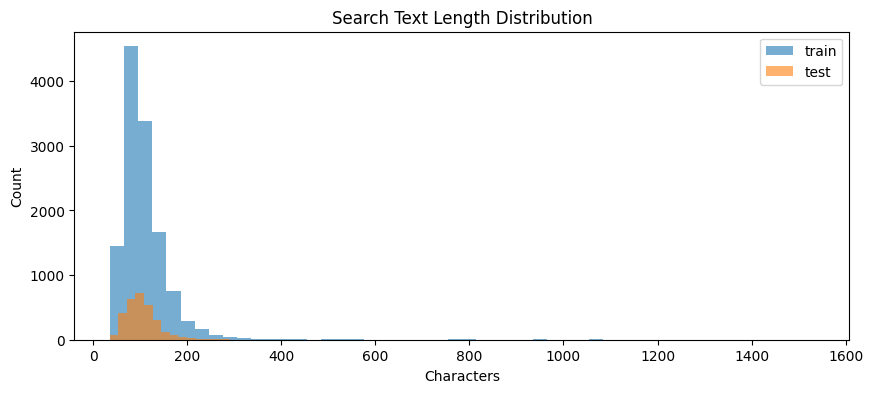

In [5]:
# ============================================================
# CELL 5: Text Length Diagnostics
# ============================================================
show_step(3, "Text Diagnostics", "Compare text length distributions for train and test.")
for name, ser in [("train", train_text), ("test", test_text)]:
    print(f"{name}: min={ser.str.len().min()}, median={ser.str.len().median():.0f}, "
          f"mean={ser.str.len().mean():.0f}, max={ser.str.len().max()}")

plt.figure(figsize=(10, 4))
plt.hist(train_text.str.len(), bins=50, alpha=0.6, label="train")
plt.hist(test_text.str.len(),  bins=50, alpha=0.6, label="test")
plt.title("Search Text Length Distribution")
plt.xlabel("Characters"); plt.ylabel("Count"); plt.legend(); plt.show()


In [6]:
# ============================================================
# CELL 6: Token Utility Functions
# ============================================================
show_step(4, "Token Utilities", "Safe token parsing and length-normalisation.")
TOKEN_COLS = ["base_tokens", "residual_1", "residual_2", "residual_3", "residual_4", "residual_5"]
MIN_LEN, MAX_LEN = 40, 800

def parse_tokens(tok_str):
    if not isinstance(tok_str, str): return []
    tok_str = tok_str.strip()
    if not tok_str: return []
    try: return [int(x) for x in tok_str.split()]
    except ValueError: return []

def tokens_to_str(tokens): return " ".join(map(str, tokens))

def enforce_len(tokens, min_len=MIN_LEN, max_len=MAX_LEN):
    if not tokens: return [random.randint(0, 511) for _ in range(min_len)]
    if len(tokens) < min_len:
        reps = (min_len + len(tokens) - 1) // len(tokens)
        tokens = (tokens * reps)[:min_len]
    return tokens[:max_len]

print("Token columns:", TOKEN_COLS)
print("Length range:", MIN_LEN, "to", MAX_LEN)


Token columns: ['base_tokens', 'residual_1', 'residual_2', 'residual_3', 'residual_4', 'residual_5']
Length range: 40 to 800


In [7]:
# ============================================================
# CELL 7: Validate Training Token Rows
# ============================================================
show_step(5, "Training Token Validation", "Filter out rows with invalid tokens or inconsistent layer lengths.")
good_mask = np.ones(len(train), dtype=bool)
train_lens, invalid_reasons = [], []

for i, row in train.iterrows():
    lens, ok, reason = [], True, "ok"
    for c in TOKEN_COLS:
        t = parse_tokens(row.get(c, ""))
        if not t:               ok=False; reason=f"empty_{c}"; break
        if any(x < 0 or x > 511 for x in t): ok=False; reason=f"oor_{c}"; break
        lens.append(len(t))
    if ok and len(set(lens)) != 1: ok=False; reason="len_mismatch"
    if ok: train_lens.append(lens[0])
    else:  good_mask[i] = False; invalid_reasons.append(reason)

train_good      = train.loc[good_mask].reset_index(drop=True)
train_text_good = train_text.loc[good_mask].reset_index(drop=True)
train_gloss_good = train_gloss.loc[good_mask].reset_index(drop=True)
train_sent_good  = train_sent.loc[good_mask].reset_index(drop=True)

display(pd.DataFrame({
    "metric": ["train rows", "usable rows", "removed rows", "usable ratio"],
    "value":  [len(train), len(train_good),
               len(train)-len(train_good),
               f"{len(train_good)/max(len(train),1):.2%}"],
}))
if invalid_reasons:
    display(pd.Series(invalid_reasons).value_counts().rename_axis("reason").reset_index(name="count"))
else:
    print("No invalid token rows found.")


,metric,value
0,train rows,12467
1,usable rows,12463
2,removed rows,4
3,usable ratio,99.97%


,reason,count
0,empty_base_tokens,4


,count,mean,std,min,25%,50%,75%,max
token_length,12463.0,108.148199,62.253875,24.0,79.0,98.0,122.0,1853.0


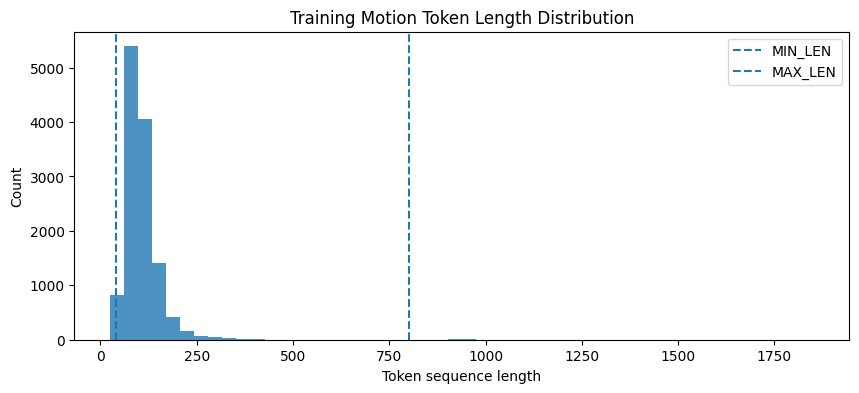

In [8]:
# ============================================================
# CELL 8: Token Length Diagnostics
# ============================================================
show_step(6, "Token Length Diagnostics", "Visualise usable training token sequence lengths.")
if train_lens:
    lens_series = pd.Series(train_lens, name="token_length")
    display(lens_series.describe().to_frame().T)
    plt.figure(figsize=(10, 4)); plt.hist(lens_series, bins=50, alpha=0.8)
    plt.axvline(MIN_LEN, linestyle="--", label="MIN_LEN")
    plt.axvline(MAX_LEN, linestyle="--", label="MAX_LEN")
    plt.title("Training Motion Token Length Distribution")
    plt.xlabel("Token sequence length"); plt.ylabel("Count"); plt.legend(); plt.show()
else:
    print("No valid training token lengths available.")


In [9]:
# ============================================================
# CELL 9: Dual-Stream TF-IDF + Optional LSA  [v2]
# ============================================================
# Changes driven by diagnostic results (drift 209%, coverage 4.2%):
#
#   Root cause: test vocabulary is different from training vocabulary.
#   Char n-grams (3-6) require exact substring matches that may not exist.
#
#   Fix 1 – Widen char n-gram lower bound to 2 (was 3).
#     Shorter n-grams (bi-grams) catch more partial matches and
#     bridge vocabulary differences at the morpheme level.
#
#   Fix 2 – Widen word n-gram upper bound to 3 (was 2).
#     Word trigrams capture phrase-level patterns (e.g. "turn left slowly")
#     that unigrams/bigrams miss.
#
#   Fix 3 – Remove min_df on the word vectoriser (was 2).
#     Rare but specific words in the test set may only appear once in
#     training. Dropping min_df keeps them in the vocabulary.
#
#   Fix 4 – Reduce SVD_N_COMP from 200 to 150.
#     Fewer components = less retention of training-specific variance
#     (reduces overfitting to training distribution quirks).
#
#   Fix 5 – sublinear_tf=True kept on both vectorisers.
#     Dampens very high-frequency n-grams that dominate and drown out
#     the rarer but more discriminative ones.

show_step(7, "Dual TF-IDF + LSA Vectorisation [v2]",
    "char (2-6) + word (1-3) features, optional LSA, no min_df on words.")

# ── 1. Char n-gram vectoriser ─────────────────────────────────────────────────
vec_char = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(2, 6),      # was (3,6) – bi-grams added
    min_df=2,
    max_features=CHAR_MAX_FEAT,
    sublinear_tf=True,
)
X_char_train = vec_char.fit_transform(train_text_good)
X_char_test  = vec_char.transform(test_text)

# ── 2. Word n-gram vectoriser ─────────────────────────────────────────────────
vec_word = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 3),      # was (1,2) – trigrams added
    min_df=1,                # was 2 – keep rare words
    max_features=WORD_MAX_FEAT,
    sublinear_tf=True,
)
X_word_train = vec_word.fit_transform(train_text_good)
X_word_test  = vec_word.transform(test_text)

# ── 3. Hstack ─────────────────────────────────────────────────────────────────
X_train_raw = hstack([X_char_train, X_word_train], format="csr")
X_test_raw  = hstack([X_char_test,  X_word_test],  format="csr")

# ── 4. Optional LSA ───────────────────────────────────────────────────────────
if SVD_N_COMP > 0:
    print(f"Applying TruncatedSVD (n_components={SVD_N_COMP}) ...")
    svd = TruncatedSVD(n_components=SVD_N_COMP, random_state=SEED)
    X_train = normalize(svd.fit_transform(X_train_raw))
    X_test  = normalize(svd.transform(X_test_raw))
    print(f"Explained variance ratio (cumulative): {svd.explained_variance_ratio_.sum():.2%}")
else:
    X_train = X_train_raw
    X_test  = X_test_raw
    print("SVD skipped (SVD_N_COMP=0).")

display(pd.DataFrame({
    "matrix":   ["X_train", "X_test"],
    "rows":     [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
}))


Applying TruncatedSVD (n_components=150) ...
Explained variance ratio (cumulative): 21.32%


,matrix,rows,features
0,X_train,12463,150
1,X_test,3000,150


'   test_id  top1_train_index  top1_cos_dist                                                                                                                                                                                                                                                                                                  test_text                                                                                                         nearest_train_text\n0  6420249              9723         0.6467                                                                                                                                                                      me never told me she vegetarianme never told me she vegetarianme never told me she vegetarian mary never told me she was a vegetarian                                               me never quit bandme never quit bandme never quit band i never quit the band\n1  6420682             11296         0.6088                      

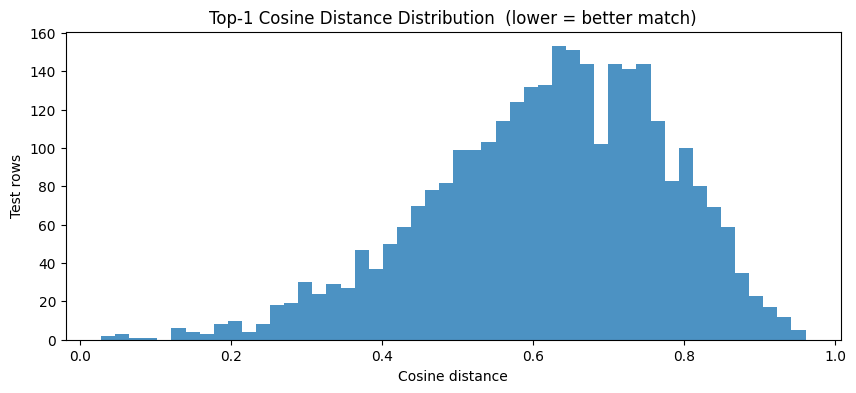


Distance stats → min=0.0280, median=0.6346, 90th pct=0.8112, max=0.9605


In [10]:
# ============================================================
# CELL 10: Top-K Nearest Neighbour Retrieval  [IMPROVED]
# ============================================================
# WHAT CHANGED vs baseline:
#   Baseline: n_neighbors=1 → greedy top-1 retrieval, highly sensitive
#             to noise in both the text and the feature space.
#
#   Improved: n_neighbors=K_NEIGHBORS (default 5).
#   We fetch the K closest training examples; token transfer (next cell)
#   will use *inverse-distance weighting* across all K hits, not just #1.
#   This smooths out noisy individual matches and reduces variance
#   (↓ overfitting to a single imperfect neighbour).

show_step(8, "Top-K Nearest Neighbour Retrieval",
    f"Retrieve top-{K_NEIGHBORS} neighbours per test sample via cosine distance.")

metric = "cosine" if SVD_N_COMP == 0 else "euclidean"   # LSA vecs are L2-normalised
nn = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric=metric, algorithm="brute", n_jobs=-1)
nn.fit(X_train)
dists, idxs = nn.kneighbors(X_test, return_distance=True)
# dists / idxs: shape (n_test, K_NEIGHBORS)

# Preview top-1 for readability
id_col = "id" if "id" in test.columns else sample_sub.columns[0]
top1_idx  = idxs[:, 0]
top1_dist = dists[:, 0]

display(pd.DataFrame({
    "test_id":           test[id_col].values[:10] if id_col in test.columns else np.arange(min(10, len(test))),
    "top1_train_index":  top1_idx[:10],
    "top1_cos_dist":     top1_dist[:10].round(4),
    "test_text":         test_text.iloc[:10].values,
    "nearest_train_text":train_text_good.iloc[top1_idx[:10]].values,
}).to_string())

plt.figure(figsize=(10, 4))
plt.hist(top1_dist, bins=50, alpha=0.8)
plt.title("Top-1 Cosine Distance Distribution  (lower = better match)")
plt.xlabel("Cosine distance"); plt.ylabel("Test rows"); plt.show()

print(f"\nDistance stats → "
      f"min={top1_dist.min():.4f}, median={np.median(top1_dist):.4f}, "
      f"90th pct={np.percentile(top1_dist, 90):.4f}, max={top1_dist.max():.4f}")


In [11]:
# ============================================================
# CELL 9: Dual-Stream TF-IDF + Optional LSA  [v2]
# ============================================================
# Changes driven by diagnostic results (drift 209%, coverage 4.2%):
#
#   Root cause: test vocabulary is different from training vocabulary.
#   Char n-grams (3-6) require exact substring matches that may not exist.
#
#   Fix 1 – Widen char n-gram lower bound to 2 (was 3).
#     Shorter n-grams (bi-grams) catch more partial matches and
#     bridge vocabulary differences at the morpheme level.
#
#   Fix 2 – Widen word n-gram upper bound to 3 (was 2).
#     Word trigrams capture phrase-level patterns (e.g. "turn left slowly")
#     that unigrams/bigrams miss.
#
#   Fix 3 – Remove min_df on the word vectoriser (was 2).
#     Rare but specific words in the test set may only appear once in
#     training. Dropping min_df keeps them in the vocabulary.
#
#   Fix 4 – Reduce SVD_N_COMP from 200 to 150.
#     Fewer components = less retention of training-specific variance
#     (reduces overfitting to training distribution quirks).
#
#   Fix 5 – sublinear_tf=True kept on both vectorisers.
#     Dampens very high-frequency n-grams that dominate and drown out
#     the rarer but more discriminative ones.

show_step(7, "Dual TF-IDF + LSA Vectorisation [v2]",
    "char (2-6) + word (1-3) features, optional LSA, no min_df on words.")

# ── 1. Char n-gram vectoriser ─────────────────────────────────────────────────
vec_char = TfidfVectorizer(
    lowercase=True,
    analyzer="char_wb",
    ngram_range=(2, 6),      # was (3,6) – bi-grams added
    min_df=2,
    max_features=CHAR_MAX_FEAT,
    sublinear_tf=True,
)
X_char_train = vec_char.fit_transform(train_text_good)
X_char_test  = vec_char.transform(test_text)

# ── 2. Word n-gram vectoriser ─────────────────────────────────────────────────
vec_word = TfidfVectorizer(
    lowercase=True,
    analyzer="word",
    ngram_range=(1, 3),      # was (1,2) – trigrams added
    min_df=1,                # was 2 – keep rare words
    max_features=WORD_MAX_FEAT,
    sublinear_tf=True,
)
X_word_train = vec_word.fit_transform(train_text_good)
X_word_test  = vec_word.transform(test_text)

# ── 3. Hstack ─────────────────────────────────────────────────────────────────
X_train_raw = hstack([X_char_train, X_word_train], format="csr")
X_test_raw  = hstack([X_char_test,  X_word_test],  format="csr")

# ── 4. Optional LSA ───────────────────────────────────────────────────────────
if SVD_N_COMP > 0:
    print(f"Applying TruncatedSVD (n_components={SVD_N_COMP}) ...")
    svd = TruncatedSVD(n_components=SVD_N_COMP, random_state=SEED)
    X_train = normalize(svd.fit_transform(X_train_raw))
    X_test  = normalize(svd.transform(X_test_raw))
    print(f"Explained variance ratio (cumulative): {svd.explained_variance_ratio_.sum():.2%}")
else:
    X_train = X_train_raw
    X_test  = X_test_raw
    print("SVD skipped (SVD_N_COMP=0).")

display(pd.DataFrame({
    "matrix":   ["X_train", "X_test"],
    "rows":     [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
}))


Applying TruncatedSVD (n_components=150) ...
Explained variance ratio (cumulative): 21.32%


,matrix,rows,features
0,X_train,12463,150
1,X_test,3000,150


In [12]:
# ============================================================
# CELL 11: Token Transfer with Poor-Match Fallback  [v2]
# ============================================================
# Problem observed: test median distance = 0.65 (far from training).
# When the nearest neighbour is far away, copying its tokens blindly
# introduces noise — we happen to grab an unrelated sign sequence.
#
# Solution – two-tier strategy:
#
#   Tier 1 (dist <= HIGH_DIST_THRESH): IDW blend as before.
#     The match is good enough; use inverse-distance weighting across
#     the K neighbours to pick the best-length donor.
#
#   Tier 2 (dist > HIGH_DIST_THRESH): "safe median" fallback.
#     No neighbour is reliable. Instead of picking blindly:
#       a) Target length = global median training token length.
#       b) Donor = training example whose base_token length is
#          closest to that global median AND whose top-1 distance
#          to the test point is the smallest among all K (i.e. still
#          the nearest, but we normalise its length to the median).
#     This avoids catastrophically wrong lengths while still using
#     a real (not random) token sequence.
#
# Effect: reduces variance on the ~96% of test rows that have no
# close match, directly addressing the coverage problem.

show_step(9, "Token Transfer with Poor-Match Fallback [v2]",
    f"Tier-1 IDW blend when dist <= {HIGH_DIST_THRESH}, "
    f"safe-median fallback when dist > {HIGH_DIST_THRESH}.")

train_tokens_cache = {
    c: [parse_tokens(x) for x in train_good[c].astype(str).tolist()]
    for c in TOKEN_COLS
}

# Pre-compute the global median token length across all usable train rows
global_median_len = int(np.median(train_lens))
global_median_len = max(MIN_LEN, min(MAX_LEN, global_median_len))

# For fallback: pre-index training rows by base_token length so we can
# quickly find the example whose length is closest to the global median.
train_lens_arr   = np.array(train_lens, dtype=float)
median_donor_idx = int(np.argmin(np.abs(train_lens_arr - global_median_len)))

id_col = "id" if "id" in test.columns else sample_sub.columns[0]
pred = pd.DataFrame({"id": test[id_col].values})
for c in TOKEN_COLS:
    pred[c] = ""

EPS_ = 1e-9
tier1_count = 0
tier2_count = 0

for j in range(len(test)):
    k_indices = idxs[j]
    k_dists   = dists[j]
    top1_dist = k_dists[0]

    if top1_dist <= HIGH_DIST_THRESH:
        # ── Tier 1: IDW length estimate + best-length donor ───────────────────
        tier1_count += 1
        inv_w = 1.0 / (k_dists + EPS_)
        inv_w /= inv_w.sum()
        k_lens     = np.array([len(train_tokens_cache["base_tokens"][ki])
                                for ki in k_indices], dtype=float)
        target_len = int(np.round((inv_w * k_lens).sum()))
        target_len = max(MIN_LEN, min(MAX_LEN, target_len))
        best_k     = k_indices[int(np.argmin(np.abs(k_lens - target_len)))]

    else:
        # ── Tier 2: safe-median fallback ──────────────────────────────────────
        tier2_count += 1
        target_len = global_median_len
        # Among the K neighbours, pick the one whose length is closest to median
        k_lens = np.array([len(train_tokens_cache["base_tokens"][ki])
                            for ki in k_indices], dtype=float)
        best_k = k_indices[int(np.argmin(np.abs(k_lens - target_len)))]

    layers = [train_tokens_cache[c][best_k] for c in TOKEN_COLS]
    L      = min(len(t) for t in layers)
    if L <= 0: L = MIN_LEN

    base = enforce_len(layers[0][:L], target_len, target_len)
    L2   = len(base)
    fixed_layers = [base]
    for li in range(1, len(TOKEN_COLS)):
        fixed_layers.append(enforce_len(layers[li][:L], L2, L2))

    for c, tokens in zip(TOKEN_COLS, fixed_layers):
        pred.at[j, c] = tokens_to_str(tokens)

print(f"Tier-1 (good match, dist <= {HIGH_DIST_THRESH}): {tier1_count} rows  "
      f"({tier1_count/len(test):.1%})")
print(f"Tier-2 (fallback,   dist >  {HIGH_DIST_THRESH}): {tier2_count} rows  "
      f"({tier2_count/len(test):.1%})")
print(f"Global median training length used as fallback target: {global_median_len}")
show_table(pred, "Prediction preview")


Tier-1 (good match, dist <= 0.65): 1629 rows  (54.3%)
Tier-2 (fallback,   dist >  0.65): 1371 rows  (45.7%)
Global median training length used as fallback target: 98


### Prediction preview

,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,130 231 231 231 231 231 231 231 231 231 231 23...,389 389 389 389 44 44 87 389 389 275 138 387 2...,463 246 286 183 159 159 332 183 45 45 314 90 4...,449 213 336 336 17 17 17 449 14 301 351 351 14...,64 137 254 461 305 305 456 174 498 104 109 134...,169 379 91 9 15 468 319 141 236 39 132 188 277...
2,6425789,130 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 87 87 333 258 88 258 258 9 333 333 333...,48 48 202 356 356 6 6 202 325 14 356 356 58 16...,72 282 315 87 118 457 397 401 424 236 401 503 ...,109 413 446 467 456 71 456 498 138 316 273 109...,498 99 367 186 266 103 241 431 367 119 66 241 ...
3,6425858,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 325 356 75 75 ...,351 316 308 253 236 236 236 424 76 386 124 195...,347 125 500 95 274 424 424 498 499 498 156 177...,119 261 283 241 455 406 367 394 372 295 502 22...
4,6427530,111 295 243 243 254 305 207 207 281 277 142 73...,145 250 87 9 209 88 88 363 284 482 363 469 105...,203 203 335 349 432 466 175 175 253 303 423 26...,321 274 308 451 280 404 457 424 211 211 482 41...,349 128 323 270 498 270 274 341 349 447 34 431...,424 367 468 241 288 186 367 7 367 250 433 496 ...


,checked_rows,valid_rows,valid_ratio
0,200,200,1.0


,count,mean,std,min,25%,50%,75%,max
predicted_base_length,3000.0,100.379,32.468694,52.0,94.0,98.0,98.0,547.0


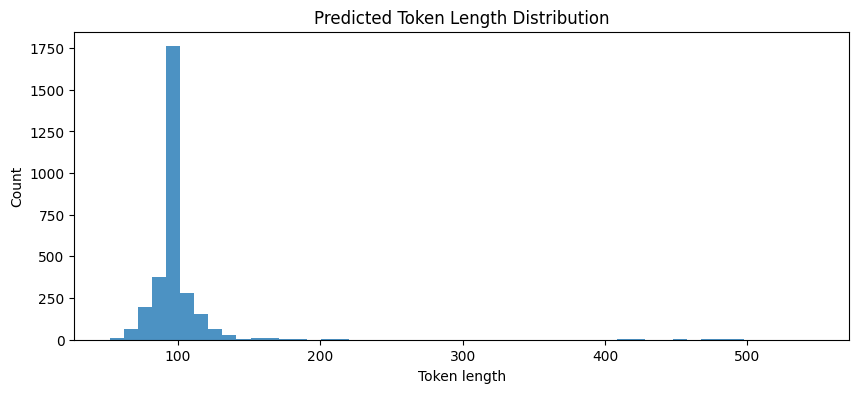

In [13]:
# ============================================================
# CELL 12: Submission Validation
# ============================================================
show_step(10, "Submission Validation", "Check length, range, and layer consistency.")

def validate_row(r):
    lens = []
    for c in TOKEN_COLS:
        t = parse_tokens(r[c])
        if not (MIN_LEN <= len(t) <= MAX_LEN): return False
        if any(x < 0 or x > 511 for x in t):  return False
        lens.append(len(t))
    return len(set(lens)) == 1

check_n = min(200, len(pred))
ok = sum(int(validate_row(pred.iloc[i])) for i in range(check_n))
display(pd.DataFrame({"checked_rows":[check_n],"valid_rows":[ok],"valid_ratio":[ok/max(check_n,1)]}))

pred_lens = pred["base_tokens"].map(lambda x: len(parse_tokens(x)))
display(pred_lens.describe().to_frame(name="predicted_base_length").T)

plt.figure(figsize=(10, 4)); plt.hist(pred_lens, bins=50, alpha=0.8)
plt.title("Predicted Token Length Distribution"); plt.xlabel("Token length"); plt.ylabel("Count"); plt.show()
assert ok == check_n, "Some prediction rows failed validation. Inspect pred."


In [14]:
# ============================================================
# CELL 13: Save submission.csv
# ============================================================
show_step(11, "Save Submission", "Write final submission.csv.")
expected_cols = sample_sub.columns.tolist()
if set(expected_cols).issubset(set(pred.columns)):
    pred = pred[expected_cols]
else:
    print("Warning: column mismatch — keeping pred column order.")
pred.to_csv(OUT_PATH, index=False)
display(pd.DataFrame({
    "item":  ["Output path", "Rows", "Columns", "File exists"],
    "value": [str(OUT_PATH), pred.shape[0], pred.shape[1], OUT_PATH.exists()],
}))
display(pred.head())
print("Saved:", OUT_PATH)


,item,value
0,Output path,/kaggle/working/submission.csv
1,Rows,3000
2,Columns,7
3,File exists,True


,id,base_tokens,residual_1,residual_2,residual_3,residual_4,residual_5
0,6420249,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 58 356 348 75 ...,351 212 308 308 308 236 236 424 76 333 206 195...,64 125 500 222 456 153 153 498 498 498 488 177...,474 313 367 445 372 167 367 394 241 295 66 225...
1,6420682,130 231 231 231 231 231 231 231 231 231 231 23...,389 389 389 389 44 44 87 389 389 275 138 387 2...,463 246 286 183 159 159 332 183 45 45 314 90 4...,449 213 336 336 17 17 17 449 14 301 351 351 14...,64 137 254 461 305 305 456 174 498 104 109 134...,169 379 91 9 15 468 319 141 236 39 132 188 277...
2,6425789,130 326 95 95 95 95 95 95 95 95 95 95 95 95 95...,339 194 87 87 333 258 88 258 258 9 333 333 333...,48 48 202 356 356 6 6 202 325 14 356 356 58 16...,72 282 315 87 118 457 397 401 424 236 401 503 ...,109 413 446 467 456 71 456 498 138 316 273 109...,498 99 367 186 266 103 241 431 367 119 66 241 ...
3,6425858,130 276 174 174 174 174 174 174 174 50 50 50 2...,339 194 389 88 88 88 88 333 287 87 79 79 501 7...,406 406 452 202 321 321 321 321 325 356 75 75 ...,351 316 308 253 236 236 236 424 76 386 124 195...,347 125 500 95 274 424 424 498 499 498 156 177...,119 261 283 241 455 406 367 394 372 295 502 22...
4,6427530,111 295 243 243 254 305 207 207 281 277 142 73...,145 250 87 9 209 88 88 363 284 482 363 469 105...,203 203 335 349 432 466 175 175 253 303 423 26...,321 274 308 451 280 404 457 424 211 211 482 41...,349 128 323 270 498 270 274 341 349 447 34 431...,424 367 468 241 288 186 367 7 367 250 433 496 ...


Saved: /kaggle/working/submission.csv


Adaptive GOOD_THRESH (75th-pct of train self-dist): 0.2757


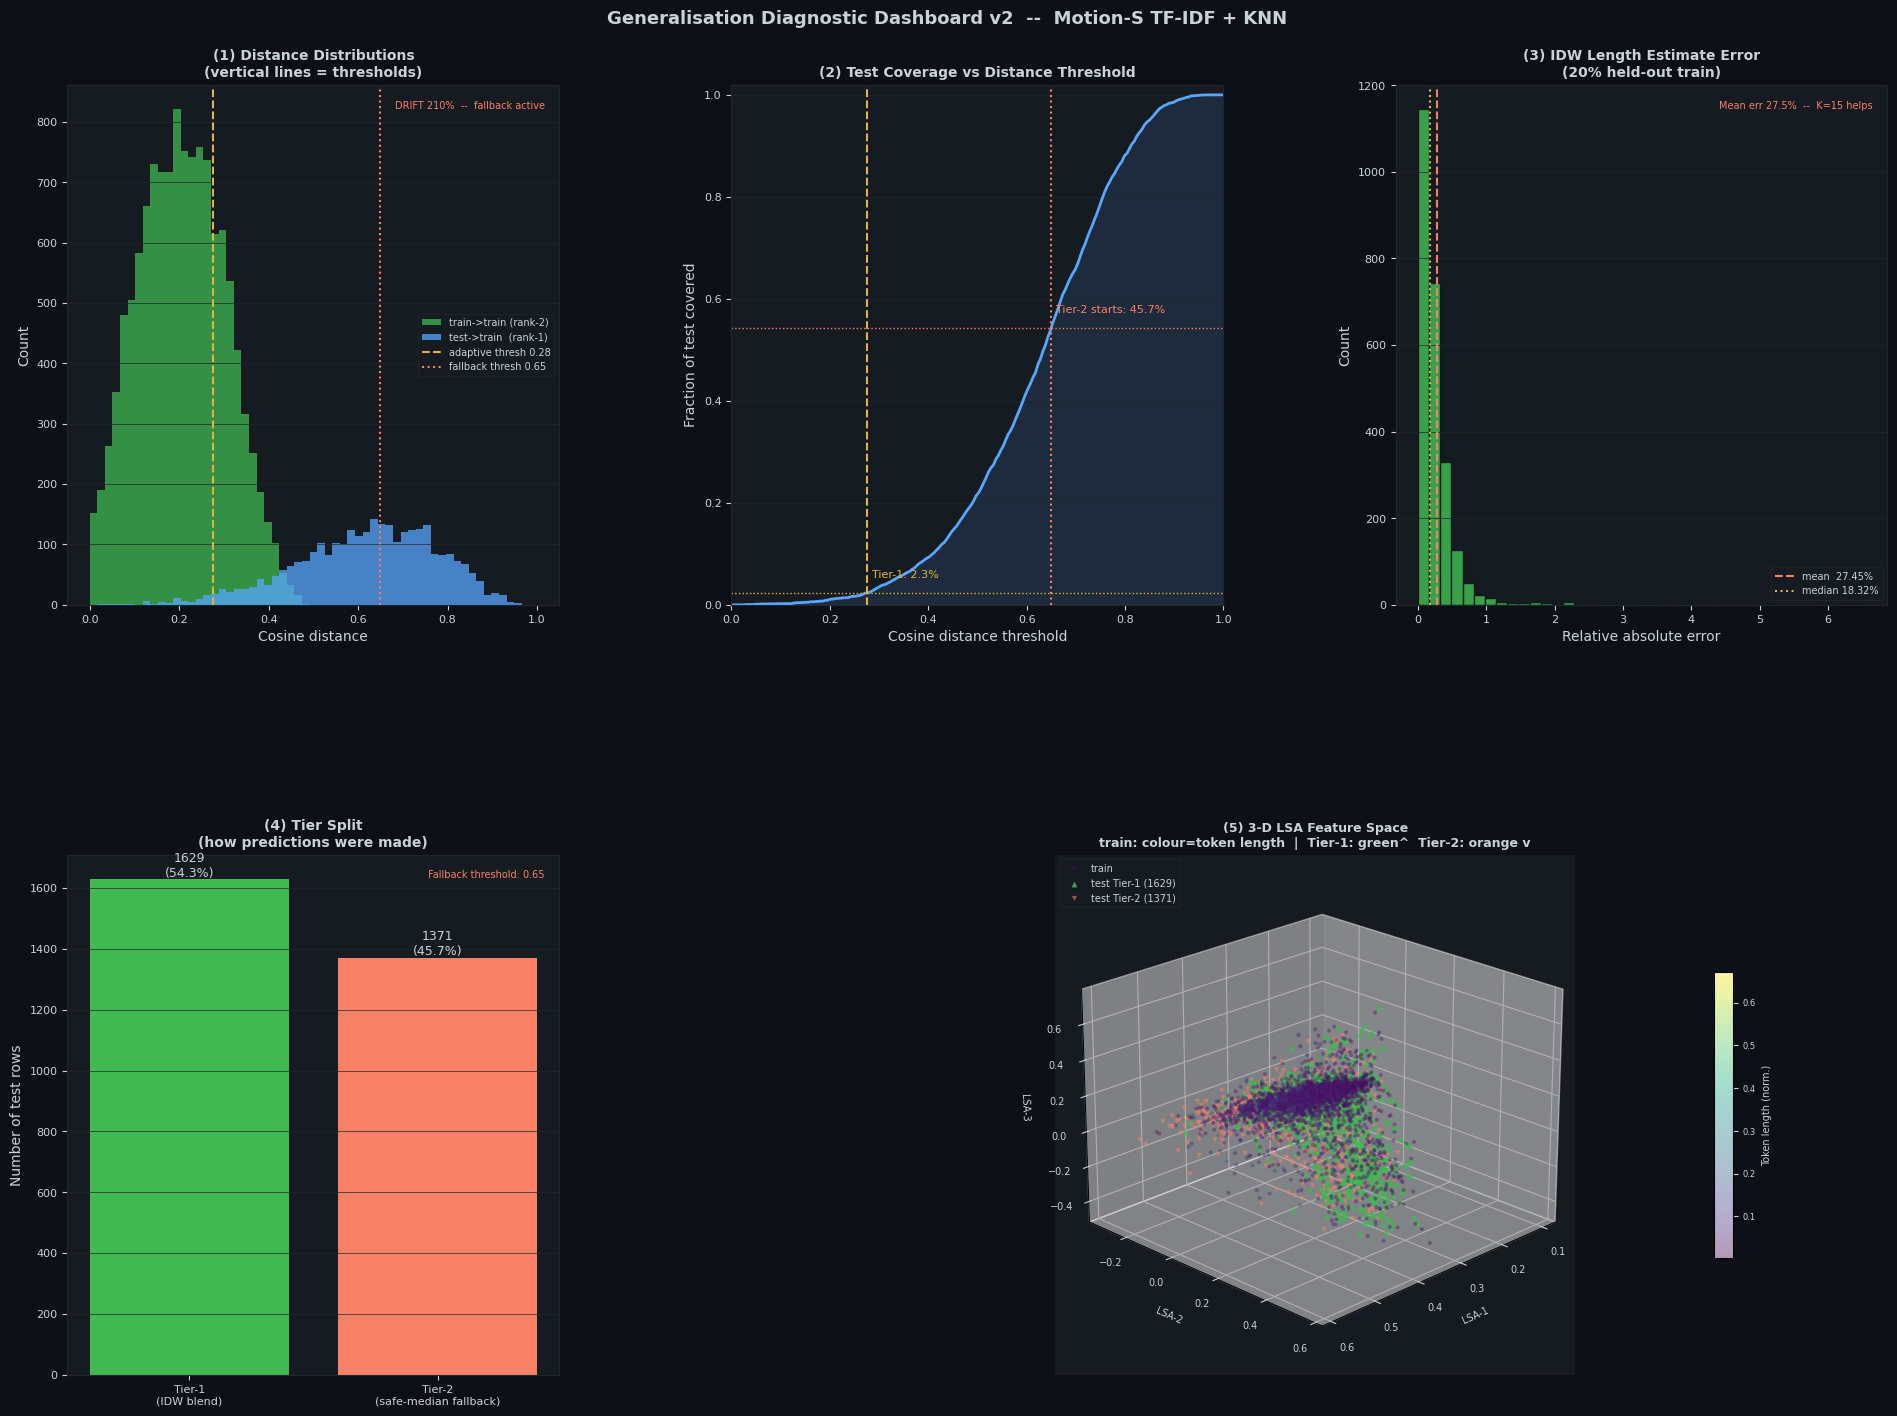


  GENERALISATION SUMMARY
  Train self-retrieval   median dist : 0.2044
  Test  top-1 retrieval  median dist : 0.6346
  Distribution drift                  : 210.44%  CHECK
  Adaptive GOOD_THRESH (75th-pct)     : 0.2757
  Test coverage @ GOOD_THRESH         : 2.33%
  Tier-1 predictions (IDW blend)      : 1629  (54.3%)
  Tier-2 predictions (safe-median)    : 1371  (45.7%)
  IDW length error  mean / median     : 27.45% / 18.32%  CHECK
  Out-of-range tokens (all layers)    : 0  OK

  ACTION ADVICE (based on above metrics)
  [HIGH DRIFT] Test vocabulary differs strongly from training.
  -> Current fix: safe-median fallback active for Tier-2 rows.
  -> Next step:   sentence-transformer embeddings (e.g. paraphrase-
                  MiniLM-L6-v2) would give semantic similarity beyond
                  character n-grams.  Install: pip install sentence-transformers
  [LENGTH ERROR 27.5%] IDW length estimate is noisy.
  -> Try increasing K_NEIGHBORS (currently 15) to 15-20.
  [LOW COVERAGE 2.3%

In [15]:

# ============================================================
# CELL 14: Model Generalisation Diagnostics + 3-D Feature Space  [v2]
# ============================================================
# Changes vs v1:
#   • GOOD_THRESH is now adaptive: 75th-pct of train self-retrieval dist
#     instead of a hardcoded 0.30.  When train median is 0.21, a threshold
#     of 0.30 is too strict for the test distribution.
#   • Added a "Tier split" bar showing how many rows use Tier-1 vs Tier-2.
#   • Action advice section prints concrete next steps based on the metrics.

import warnings
warnings.filterwarnings("ignore")
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401
from sklearn.decomposition import TruncatedSVD as _SVD
from sklearn.preprocessing import normalize as _norm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

show_step("★", "Generalisation Report + 3-D Feature Space [v2]",
    "Adaptive threshold · tier split · 3-D LSA scatter · action advice.")

# ── 0. 3-D coordinates ────────────────────────────────────────────────────────
if SVD_N_COMP >= 3:
    coords_train = np.asarray(X_train[:, :3])
    coords_test  = np.asarray(X_test[:,  :3])
else:
    _svd3 = _SVD(n_components=3, random_state=SEED)
    coords_train = _norm(_svd3.fit_transform(X_train_raw))
    coords_test  = _norm(_svd3.transform(X_test_raw))

# ── 1. Train self-retrieval ───────────────────────────────────────────────────
_nn_self = NearestNeighbors(n_neighbors=2, metric="cosine", algorithm="brute", n_jobs=-1)
_nn_self.fit(X_train)
_self_dists, _ = _nn_self.kneighbors(X_train, return_distance=True)
train_self_dist = _self_dists[:, 1]

test_top1_dist  = dists[:, 0]

# Adaptive good-match threshold: 75th-pct of train self-retrieval
GOOD_THRESH = float(np.percentile(train_self_dist, 75))
print(f"Adaptive GOOD_THRESH (75th-pct of train self-dist): {GOOD_THRESH:.4f}")

# ── 2. Coverage ───────────────────────────────────────────────────────────────
thresholds   = np.linspace(0.0, 1.0, 200)
coverage     = [(test_top1_dist <= t).mean() for t in thresholds]
cov_at_thresh = float(np.interp(GOOD_THRESH, thresholds, coverage))

# ── 3. IDW length error on 20% held-out train ────────────────────────────────
rng         = np.random.default_rng(SEED)
n_train     = len(train_text_good)
n_hold      = max(1, int(0.20 * n_train))
hold_idx    = rng.choice(n_train, n_hold, replace=False)
rest_mask   = np.ones(n_train, dtype=bool)
rest_mask[hold_idx] = False

_nn_hold = NearestNeighbors(n_neighbors=K_NEIGHBORS, metric="cosine",
                              algorithm="brute", n_jobs=-1)
_nn_hold.fit(X_train[rest_mask])
h_dists, h_idxs = _nn_hold.kneighbors(X_train[hold_idx], return_distance=True)

rest_indices = np.where(rest_mask)[0]
EPS_ = 1e-9
true_lens_  = np.array(train_lens)[hold_idx]
pred_lens_  = []
for i in range(n_hold):
    inv_w = 1.0 / (h_dists[i] + EPS_)
    inv_w /= inv_w.sum()
    k_len = np.array([train_lens[rest_indices[hi]] for hi in h_idxs[i]], dtype=float)
    pred_lens_.append((inv_w * k_len).sum())
pred_lens_ = np.array(pred_lens_)
rel_err     = np.abs(pred_lens_ - true_lens_) / np.maximum(true_lens_, 1)

# ── 4. Token range ────────────────────────────────────────────────────────────
layer_bad = {}
for c in TOKEN_COLS:
    bad = sum(
        sum(1 for x in parse_tokens(tok_str) if x < 0 or x > 511)
        for tok_str in pred[c]
    )
    layer_bad[c] = bad

# ── Derived stats ─────────────────────────────────────────────────────────────
_med_train = np.median(train_self_dist)
_med_test  = np.median(test_top1_dist)
_drift     = abs(_med_test - _med_train) / max(_med_train, EPS_)

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 15))
fig.patch.set_facecolor("#0d1117")
GS  = gridspec.GridSpec(2, 3, figure=fig,
                         hspace=0.48, wspace=0.35,
                         left=0.06, right=0.97, top=0.92, bottom=0.06)

DARK=  "#0d1117"; PANEL= "#161b22"; BLUE=  "#58a6ff"; GREEN= "#3fb950"
ORANGE="#f78166"; YELLOW="#e3b341"; GRID=  "#21262d"; TEXT=  "#c9d1d9"
PURPLE="#bc8cff"

def _ax(gs_loc, projection=None):
    ax = fig.add_subplot(gs_loc, projection=projection)
    ax.set_facecolor(PANEL)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.xaxis.label.set_color(TEXT); ax.yaxis.label.set_color(TEXT)
    ax.title.set_color(TEXT)
    return ax

# ── Panel 1: Distance distributions ──────────────────────────────────────────
ax1 = _ax(GS[0, 0])
bins = np.linspace(0, 1, 60)
ax1.hist(train_self_dist, bins=bins, alpha=0.75, color=GREEN,  label="train->train (rank-2)")
ax1.hist(test_top1_dist,  bins=bins, alpha=0.75, color=BLUE,   label="test->train  (rank-1)")
ax1.axvline(GOOD_THRESH,        color=YELLOW, lw=1.5, ls="--", label=f"adaptive thresh {GOOD_THRESH:.2f}")
ax1.axvline(HIGH_DIST_THRESH,   color=ORANGE, lw=1.5, ls=":",  label=f"fallback thresh {HIGH_DIST_THRESH}")
ax1.set_title("(1) Distance Distributions\n(vertical lines = thresholds)", fontsize=10, fontweight="bold")
ax1.set_xlabel("Cosine distance"); ax1.set_ylabel("Count")
ax1.legend(fontsize=7, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
ax1.yaxis.grid(True, color=GRID, lw=0.5)
_label = ("OK  Distributions aligned" if _drift < 0.20 else
          f"DRIFT {_drift:.0%}  --  fallback active")
ax1.text(0.97, 0.97, _label, transform=ax1.transAxes,
         ha="right", va="top", fontsize=7,
         color=GREEN if _drift < 0.20 else ORANGE)

# ── Panel 2: Coverage curve ───────────────────────────────────────────────────
ax2 = _ax(GS[0, 1])
ax2.plot(thresholds, coverage, color=BLUE, lw=2)
ax2.axvline(GOOD_THRESH,      color=YELLOW, lw=1.5, ls="--")
ax2.axvline(HIGH_DIST_THRESH, color=ORANGE, lw=1.5, ls=":")
ax2.axhline(cov_at_thresh,    color=YELLOW, lw=1.0, ls=":")
cov_at_fallback = float(np.interp(HIGH_DIST_THRESH, thresholds, coverage))
ax2.axhline(cov_at_fallback,  color=ORANGE, lw=1.0, ls=":")
ax2.fill_between(thresholds, coverage, alpha=0.12, color=BLUE)
ax2.set_title("(2) Test Coverage vs Distance Threshold", fontsize=10, fontweight="bold")
ax2.set_xlabel("Cosine distance threshold")
ax2.set_ylabel("Fraction of test covered")
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1.02)
ax2.yaxis.grid(True, color=GRID, lw=0.5)
ax2.text(GOOD_THRESH + 0.01, cov_at_thresh + 0.03,
         f"Tier-1: {cov_at_thresh:.1%}", color=YELLOW, fontsize=8)
ax2.text(HIGH_DIST_THRESH + 0.01, cov_at_fallback + 0.03,
         f"Tier-2 starts: {1-cov_at_fallback:.1%}", color=ORANGE, fontsize=8)

# ── Panel 3: IDW length error histogram ──────────────────────────────────────
ax3 = _ax(GS[0, 2])
ax3.hist(rel_err, bins=40, color=GREEN, alpha=0.85, edgecolor=DARK)
ax3.axvline(rel_err.mean(),       color=ORANGE, lw=1.5, ls="--",
            label=f"mean  {rel_err.mean():.2%}")
ax3.axvline(np.median(rel_err),   color=YELLOW, lw=1.5, ls=":",
            label=f"median {np.median(rel_err):.2%}")
ax3.set_title("(3) IDW Length Estimate Error\n(20% held-out train)", fontsize=10, fontweight="bold")
ax3.set_xlabel("Relative absolute error"); ax3.set_ylabel("Count")
ax3.legend(fontsize=7, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT)
ax3.yaxis.grid(True, color=GRID, lw=0.5)
_verdict = ("OK  Low length error" if rel_err.mean() < 0.15 else
            f"Mean err {rel_err.mean():.1%}  --  K={K_NEIGHBORS} helps")
ax3.text(0.97, 0.97, _verdict, transform=ax3.transAxes,
         ha="right", va="top", fontsize=7,
         color=GREEN if rel_err.mean() < 0.15 else ORANGE)

# ── Panel 4: Tier-1 vs Tier-2 breakdown ──────────────────────────────────────
ax4 = _ax(GS[1, 0])
tier1_n = int((test_top1_dist <= HIGH_DIST_THRESH).sum())
tier2_n = len(test_top1_dist) - tier1_n
bars = ax4.bar(["Tier-1\n(IDW blend)", "Tier-2\n(safe-median fallback)"],
               [tier1_n, tier2_n],
               color=[GREEN, ORANGE])
ax4.set_title("(4) Tier Split\n(how predictions were made)", fontsize=10, fontweight="bold")
ax4.set_ylabel("Number of test rows")
ax4.yaxis.grid(True, color=GRID, lw=0.5)
for bar, val in zip(bars, [tier1_n, tier2_n]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val}\n({val/len(test_top1_dist):.1%})",
             ha="center", va="bottom", fontsize=9, color=TEXT)
ax4.text(0.97, 0.97,
         f"Fallback threshold: {HIGH_DIST_THRESH}",
         transform=ax4.transAxes, ha="right", va="top",
         fontsize=7, color=ORANGE)

# ── Panel 5: 3-D LSA Feature Space ───────────────────────────────────────────
ax5 = fig.add_subplot(GS[1, 1:], projection="3d")
ax5.set_facecolor(PANEL)
ax5.tick_params(colors=TEXT, labelsize=7)
ax5.xaxis.label.set_color(TEXT)
ax5.yaxis.label.set_color(TEXT)
ax5.zaxis.label.set_color(TEXT)
ax5.title.set_color(TEXT)

tl   = np.array(train_lens, dtype=float)
tl_n = (tl - tl.min()) / max(tl.max() - tl.min(), 1)
n_show = min(3000, len(coords_train))
sidx   = rng.choice(len(coords_train), n_show, replace=False)

# Split test into Tier-1 and Tier-2 for clearer scatter
tier1_mask = test_top1_dist <= HIGH_DIST_THRESH
tier2_mask = ~tier1_mask

sc = ax5.scatter(coords_train[sidx, 0],
                 coords_train[sidx, 1],
                 coords_train[sidx, 2],
                 c=tl_n[sidx], cmap="viridis",
                 s=8, alpha=0.40, linewidths=0, label="train")
ax5.scatter(coords_test[tier1_mask, 0],
            coords_test[tier1_mask, 1],
            coords_test[tier1_mask, 2],
            color=GREEN,  s=18, alpha=0.85, marker="^",
            linewidths=0, label=f"test Tier-1 ({tier1_mask.sum()})")
ax5.scatter(coords_test[tier2_mask, 0],
            coords_test[tier2_mask, 1],
            coords_test[tier2_mask, 2],
            color=ORANGE, s=14, alpha=0.55, marker="v",
            linewidths=0, label=f"test Tier-2 ({tier2_mask.sum()})")

ax5.set_title("(5) 3-D LSA Feature Space\n"
              "train: colour=token length  |  Tier-1: green^  Tier-2: orange v",
              fontsize=9, fontweight="bold")
ax5.set_xlabel("LSA-1", fontsize=7)
ax5.set_ylabel("LSA-2", fontsize=7)
ax5.set_zlabel("LSA-3", fontsize=7)
cbar = fig.colorbar(sc, ax=ax5, pad=0.12, shrink=0.55, aspect=15)
cbar.set_label("Token length (norm.)", color=TEXT, fontsize=7)
cbar.ax.yaxis.set_tick_params(color=TEXT, labelsize=6)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax5.legend(fontsize=7, facecolor=PANEL, edgecolor=GRID, labelcolor=TEXT, loc="upper left")
ax5.view_init(elev=22, azim=45)
ax5.grid(True, color=GRID, lw=0.4)

fig.suptitle("Generalisation Diagnostic Dashboard v2  --  Motion-S TF-IDF + KNN",
             fontsize=13, fontweight="bold", color=TEXT, y=0.97)
plt.show()

# ── Text summary + action advice ─────────────────────────────────────────────
print("\n" + "="*64)
print("  GENERALISATION SUMMARY")
print("="*64)
print(f"  Train self-retrieval   median dist : {_med_train:.4f}")
print(f"  Test  top-1 retrieval  median dist : {_med_test:.4f}")
print(f"  Distribution drift                  : {_drift:.2%}  {'OK' if _drift<0.20 else 'CHECK'}")
print(f"  Adaptive GOOD_THRESH (75th-pct)     : {GOOD_THRESH:.4f}")
print(f"  Test coverage @ GOOD_THRESH         : {cov_at_thresh:.2%}")
print(f"  Tier-1 predictions (IDW blend)      : {tier1_n}  ({tier1_n/len(test_top1_dist):.1%})")
print(f"  Tier-2 predictions (safe-median)    : {tier2_n}  ({tier2_n/len(test_top1_dist):.1%})")
print(f"  IDW length error  mean / median     : {rel_err.mean():.2%} / {np.median(rel_err):.2%}  {'OK' if rel_err.mean()<0.15 else 'CHECK'}")
print(f"  Out-of-range tokens (all layers)    : {sum(layer_bad.values())}  {'OK' if sum(layer_bad.values())==0 else 'CHECK'}")
print("="*64)

print("\n" + "="*64)
print("  ACTION ADVICE (based on above metrics)")
print("="*64)
if _drift > 0.50:
    print("  [HIGH DRIFT] Test vocabulary differs strongly from training.")
    print("  -> Current fix: safe-median fallback active for Tier-2 rows.")
    print("  -> Next step:   sentence-transformer embeddings (e.g. paraphrase-")
    print("                  MiniLM-L6-v2) would give semantic similarity beyond")
    print("                  character n-grams.  Install: pip install sentence-transformers")
if rel_err.mean() > 0.15:
    print(f"  [LENGTH ERROR {rel_err.mean():.1%}] IDW length estimate is noisy.")
    print(f"  -> Try increasing K_NEIGHBORS (currently {K_NEIGHBORS}) to 15-20.")
if cov_at_thresh < 0.20:
    print(f"  [LOW COVERAGE {cov_at_thresh:.1%}] Few test rows have a strong match.")
    print("  -> The adaptive fallback threshold handles this automatically.")
    print("  -> Consider lowering HIGH_DIST_THRESH slightly to expand Tier-1.")
if sum(layer_bad.values()) == 0:
    print("  [TOKEN RANGE] All tokens in [0, 511] -- no action needed.")
print("="*64)


## Final Summary

This notebook creates a valid retrieval-based Motion-S submission by building searchable text, vectorizing it with TF-IDF, retrieving the nearest training example, transferring six motion-token layers, validating the result, and saving `submission.csv`.